# Q3 — Enrollment Performance

How does enrollment vary across phases, therapeutic areas, and sponsor types?  
What are the typical enrollment sizes, and how do they relate to trial success?

---

## Setup

In [33]:
# ── Setup ──────────────────────────────────────────────────────────────────
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sqlalchemy import create_engine, text

# ─────────────────────────────────────────
# CONFIG — update username if needed
# ─────────────────────────────────────────
DB_USER = "vittoriobariosco"  # your username
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "clinical_trials" # your PostgreSQL database name 
CSV_PATH = "/Users/vittoriobariosco/Documents/APPLICATIONS/MIGx/data/processed/clinical_trials_clean.csv"  #path to cleaned CSV from EDA notebook

# ─────────────────────────────────────────
# 1. CONNECT TO POSTGRESQL
# ─────────────────────────────────────────
engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}@{DB_HOST}:{DB_PORT}/{DB_NAME}")


# --- Style Guide ---
COLORS = {
    'primary': '#2563EB',
    'success': '#10B981',
    'danger': '#EF4444',
    'accent': '#F59E0B',
    'secondary': '#64748B',
    'light_gray': '#F1F5F9',
    'dark': '#1E293B'
}

PALETTE = [COLORS['primary'], COLORS['success'], COLORS['danger'],
           COLORS['accent'], COLORS['secondary'], '#8B5CF6', '#EC4899', '#06B6D4']

def style_fig(fig, title='', height=500, width=None, showlegend=True):
    """Apply consistent corporate styling to a Plotly figure."""
    fig.update_layout(
        title=dict(text=title, font=dict(family='Helvetica Neue', size=18, color=COLORS['dark']),
                   x=0, xanchor='left', pad=dict(l=10, t=10)),
        font=dict(family='Helvetica Neue', size=12, color=COLORS['dark']),
        plot_bgcolor='white',
        paper_bgcolor='white',
        height=height,
        width=width,
        showlegend=showlegend,
        margin=dict(l=60, r=30, t=60, b=50),
        legend=dict(bgcolor='rgba(0,0,0,0)', font=dict(size=11))
    )
    fig.update_xaxes(showgrid=False, linecolor='#E2E8F0', linewidth=1)
    fig.update_yaxes(showgrid=True, gridcolor='#F1F5F9', linecolor='#E2E8F0', linewidth=1)
    return fig

print('Setup OK — connected to PostgreSQL')

Setup OK — connected to PostgreSQL


---
## Query 3A — Enrollment Distribution by Phase


In [34]:
query_3a = """
SELECT
    study_type,
    phase,
    COUNT(*) AS n_trials,
    ROUND(
        PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY enrollment)::numeric, 0
    ) AS enrollment_q1,
    ROUND(
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY enrollment)::numeric, 0
    ) AS enrollment_median,
    ROUND(
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY enrollment)::numeric, 0
    ) AS enrollment_q3,
    MAX(enrollment) AS enrollment_max
FROM studies
WHERE
    enrollment > 0           
    AND phase != 'Unknown'   
GROUP BY study_type, phase
ORDER BY study_type, phase;
"""

df_3a = pd.read_sql(query_3a, engine)
df_3a

,study_type,phase,n_trials,enrollment_q1,enrollment_median,enrollment_q3,enrollment_max
0,Interventional,Early Phase 1,43,20.0,40.0,100.0,400
1,Interventional,Not Applicable,1335,50.0,108.0,360.0,20000000
2,Interventional,Phase 1,227,24.0,40.0,62.0,5000
3,Interventional,Phase 2,843,44.0,100.0,200.0,200000
4,Interventional,Phase 3,624,128.0,346.0,1000.0,500000
5,Interventional,Phase 4,154,56.0,150.0,773.0,80000


In [64]:
# Chart 3A-1: Box-style comparison — Median enrollment by phase with IQR
# Sort by median for visual clarity
df_plot = df_3a.sort_values('enrollment_median', ascending=True)

# 1. Define colors: Accent (Amber) for non-standard phases, Primary (Blue) for the rest
bar_colors = [
    COLORS['accent'] if p in ['Not Applicable', 'Unknown'] else COLORS['primary'] 
    for p in df_plot['phase']
]

fig = go.Figure()

# 2. Add the Bar trace with the dynamic color list
fig.add_trace(go.Bar(
    y=df_plot['phase'],
    x=df_plot['enrollment_median'],
    orientation='h',
    marker_color=bar_colors,
    name='Median',
    hoverinfo='skip' # Optional: keeps the focus on the markers/labels
))

# 3. Add IQR as error bars (Keep as is)
fig.add_trace(go.Scatter(
    y=df_plot['phase'],
    x=df_plot['enrollment_median'],
    error_x=dict(
        type='data',
        symmetric=False,
        array=(df_plot['enrollment_q3'] - df_plot['enrollment_median']).tolist(),
        arrayminus=(df_plot['enrollment_median'] - df_plot['enrollment_q1']).tolist(),
        color=COLORS['secondary'],
        thickness=2
    ),
    mode='markers',
    marker=dict(size=10, color=COLORS['accent'], symbol='diamond'),
    name='IQR (Q1–Q3)',
    showlegend=True
))

for _, row in df_plot.iterrows():
    # A. MEDIAL VALUE ANNOTATION (Above and slightly right of the bar end)
    fig.add_annotation(
        y=row['phase'],
        x=row['enrollment_median'],
        text=f"<b>{row['enrollment_median']:,.0f}</b>", # Bolded here
        showarrow=False,
        font=dict(size=12, color=COLORS['dark']),
        yshift=14,                # <--- TUNE THIS: Positive moves text TOP
        xshift=8,                # <--- TUNE THIS: Positive moves text RIGHT
        xanchor='left'            # Anchor left to help the 'right' shift feel natural
    )

# 4. Add n_trials annotation (Keep as is)
for _, row in df_plot.iterrows():
    fig.add_annotation(
        y=row['phase'], 
        x=row['enrollment_q3'] + (row['enrollment_q3'] * 0.15),
        text=f"n={row['n_trials']:,}",
        showarrow=False, 
        font=dict(size=11, color=COLORS['dark']),
        yshift=11, 
        xshift=32,            # Moves the text 18 pixels ABOVE the bar
        xanchor='center',
)

style_fig(fig, title='Median Enrollment by Phase (Highlighted Unknown)', height=420, width=700)
fig.update_xaxes(title_text='Enrollment')
fig.update_layout(
    showlegend=True,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
)
fig.show()

### Analysis — Enrollment Distribution by Phase

**Key Findings:**

* **Clear Correlation between Phase and Scale:** Enrollment follows the clinical progression, with the median size increasing from **40** in Phase 1 to **100** in Phase 2, and peaking at **346** in Phase 3. Phase 3 trials are roughly **8.6 times larger** than Phase 1 trials.
* **The outlier (unknown):** This category represents the largest volume of trials ($n=1,335$) and contains a massive outlier with **20,000,000** participants. While the **median (108)** remains modest, the extreme maximum illustrates why reporting the mean would lead to a significant misrepresentation of typical trial size.

These results confirm that **Median Enrollment** is the only reliable metric for "typical" trial size. Using the mean would allow single population-level registries (like the 20M study) to distort the perception of standard clinical research.


---
## Query 3B — Enrollment by Therapeutic Area



In [65]:
query_3b = """
WITH condition_enrollment AS (
    SELECT
        c.condition_name,
        c.therapeutic_area,
        COUNT(DISTINCT s.study_id) AS n_trials,
        SUM(s.enrollment) AS total_enrollment,
        ROUND(
            PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY s.enrollment)::numeric,
            0
        ) AS median_enrollment_per_trial
    FROM studies s
    JOIN conditions c ON s.study_id = c.study_id
    WHERE s.enrollment > 0
    GROUP BY c.condition_name, c.therapeutic_area
)

SELECT
    condition_name,
    therapeutic_area,
    n_trials,
    total_enrollment,
    median_enrollment_per_trial,
    RANK() OVER(ORDER BY total_enrollment DESC) AS enrollment_rank

FROM condition_enrollment
ORDER BY enrollment_rank
LIMIT 20;
"""

df_3b = pd.read_sql(query_3b, engine)
df_3b

,condition_name,therapeutic_area,n_trials,total_enrollment,median_enrollment_per_trial,enrollment_rank
0,COVID-19,Infectious Disease,4412,118674861,200.0,1
1,Appendicitis,Other,3,6000250,200.0,2
2,Diabetes,Metabolic/Cardiovascular,18,2248123,1211.0,3
3,Obesity,Metabolic/Cardiovascular,25,2012844,198.0,4
4,Blood Donation,Other,4,1386060,430026.0,5
5,Patient Preference,Other,2,1200517,600259.0,6
6,"Influenza, Human",Infectious Disease,8,821401,1576.0,7
7,Sars (Severe Acute Respiratory Syndrome),Infectious Disease,33,519578,200.0,8
8,Cancer,Oncology,60,418790,400.0,9
9,Anxiety,Mental Health,100,371195,300.0,10


In [9]:
# Chart 3B: Horizontal bar — median enrollment by therapeutic area
df_plot = df_3b.sort_values('median_enrollment', ascending=True)

fig = go.Figure()
fig.add_trace(go.Bar(
    y=df_plot['therapeutic_area'],
    x=df_plot['median_enrollment'],
    orientation='h',
    marker_color=COLORS['primary'],
    text=df_plot.apply(lambda r: f"{r['median_enrollment']:,.0f}  (n={r['n_trials']:,})", axis=1),
    textposition='outside',
    textfont=dict(size=10)
))

style_fig(fig, title='Median Enrollment by Therapeutic Area', height=450)
fig.update_xaxes(title_text='Median Enrollment')
fig.show()

In [28]:
# --- Chart 3B-1: Participation Leaderboard (Top 8 - Log Scale) ---

# 1. Filter for the top 8 conditions by total enrollment
# We sort ascending=True at the end so the largest bar appears at the top of the horizontal chart
df_top8 = df_3b.nlargest(8, 'total_enrollment').sort_values('total_enrollment', ascending=True)

fig_3b1 = go.Figure()
fig_3b1.add_trace(go.Bar(
    y=df_top8['condition_name'],
    x=df_top8['total_enrollment'],
    orientation='h',
    marker_color=COLORS['primary'],
    # Formatting text labels for Millions (M) and Thousands (K)
    text=df_top8['total_enrollment'].apply(lambda x: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"),
    textposition='outside',
    hovertemplate="<b>%{y}</b><br>Total Enrollment: %{x:,.0f}<br>Trials: %{customdata}<extra></extra>",
    customdata=df_top8['n_trials']
))

# 2. Apply styling
style_fig(fig_3b1, title='<b>Top 8 Conditions by Total Enrollment (Logarithmic Scale)</b>', height=450)

# Maintain the Log Scale to handle the 118M vs 500K disparity
fig_3b1.update_xaxes(type="log", title_text='Total Participants (Log Scale)')

# Ensure enough margin for the condition names
fig_3b1.update_layout(margin=dict(l=150, r=80, t=80, b=50))

fig_3b1.show()

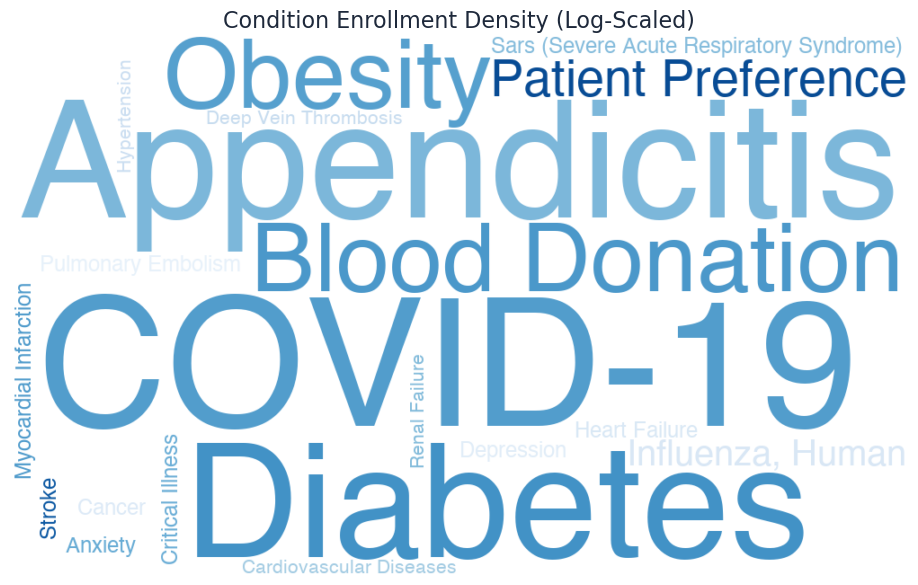

In [26]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare frequency dictionary using log-scaling
# This prevents one outlier (COVID) from swallowing the whole graphic
freq_dict = {
    row['condition_name']: np.log10(row['total_enrollment']) 
    for _, row in df_3b.iterrows()
}

# 2. Generate Word Cloud
wordcloud = WordCloud(
    width=1000, 
    height=600, 
    background_color='white',
    colormap='Blues',       # Matches your corporate 'primary' theme
    prefer_horizontal=0.7,
    relative_scaling=0.5,
    font_path='Helvetica'   # Matches your style guide
).generate_from_frequencies(freq_dict)

# 3. Plot
plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Condition Enrollment Density (Log-Scaled)', fontsize=16, color=COLORS['dark'])
plt.show()

### ## Summary & Recommendations

---

* **The COVID-19 Phenomenon:** COVID-19 leads, attracting **118.7 million** participants—nearly **20 times more** than the next closest condition. However, its **median enrollment of 200** per trial suggests that this volume was achieved through a massive quantity of mid-sized studies ($n=4,412$) rather than a few monolithic ones.
---

* **Which conditions attract the most participants?**
    **COVID-19** attracts the most participants globally, followed by **Metabolic/Cardiovascular** conditions (Appendicities, Diabetes, Obesity).
* **What are the trends across different trial types?**
    There is a significant trend toward **Observational Registries** in areas (Appendicitis, Blood Donation) which capture millions of data points with very few trials. Conversely, **Interventional Drug Research** (Oncology, Respiratory) follows a trend of "Standardized Scaling," maintaining consistent recruitment targets between **200 and 500 participants** across a high volume of independent studies.